In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker, DrawingArea
from matplotlib.offsetbox import DrawingArea, VPacker, OffsetImage, TextArea, AnchoredOffsetbox
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker

from PIL import Image

phenomena = {
    "Tornado": (0.5, 0.25),               # km, hours
    "Isolated Thunderstorm": (10, 6),
    # "Narrow Cold Frontal Rainband": (80, 12),
    "Squall Line": (100, 18),
    "Mesoscale Convective System": (200, 48),
    "Hurricane": (500, 5*24),
    "Atmospheric River": (1500, 7.5*24),
    "Drought": (5000, 14*24),
}

# reference time lines
time_lines = {
    "Hour":1,
    "Day":24,
    "Week":168,
    "Month":720,
    "Year":8760
}

image_paths = {
    "Tornado": "icons/tornado.png",
    "Isolated Thunderstorm": "icons/thunderstorm.png",
    # "Narrow Cold Frontal Rainband": "icons/NCFR.png",
    "Squall Line": "icons/squall.png",
    "Mesoscale Convective System": "icons/mcs.png",
    "Hurricane": "icons/hurricane.png",
    "Atmospheric River": "icons/atmospheric_river.png",
    "Drought": "icons/drought.png"
}


def plot_predictability_presentation(phenomena, time_lines, image_paths):

    fig, ax = plt.subplots(figsize=(11,8))

    ax.set_xscale("log")
    ax.set_yscale("log")

    # ---------------------------
    # Scatter points
    # ---------------------------
    for i, (name, (x, y)) in enumerate(phenomena.items()):

        ax.scatter(x, y, s=150, color='#00629B', edgecolor="#747678", zorder=4)
        # Alternate placement
        # y_offset = -60 if i == 1 else (60 if i % 2 == 0 else -55)
        y_offset = -65 if i == 1 else (55 if i % 2 == 0 else -60)
        # --- Force consistent label formatting ---
        pretty_names = {
            "Atmospheric River": "Atmospheric\nRiver",
            "Narrow Cold Frontal Rainband": "Narrow Cold\nFrontal Rainband",
            "Isolated Thunderstorm": "Isolated\nThunderstorm",
            "Mesoscale Convective System": "Mesoscale\nConvective System",
            # "Squall Line": "Squall\nLine"
        }
        label_text = pretty_names.get(name, name)
        
        # Load image (already same size)
        img = Image.open(image_paths[name])
        imagebox = OffsetImage(img, zoom=0.6)
        
        # force same text width
        label = TextArea(
            label_text,
            textprops=dict(size=10, ha='center', color='white'),
            # minimumdescent=False
        )
        
        # Stack image + label
        box = VPacker(
            children=[imagebox, label],
            align="center",
            pad=0,
            sep=5
        )
        
        # Final annotation
        ab = AnnotationBbox(
                box,
                (x, y),
                xybox=(0, y_offset),
                xycoords='data',
                boxcoords="offset points",
                frameon=True,
                bboxprops=dict(
                    boxstyle="round,pad=0.6",
                    fc="#00629B",
                    ec="#747678",
                    lw=1
                ),
                arrowprops=dict(
                    arrowstyle="-",
                    color="#747678",
                    lw=1.5
                ),
                zorder=2
            )
                
        ax.add_artist(ab)

    # ---------------------------
    # Horizontal reference lines
    # ---------------------------
    for label, val in time_lines.items():
        ax.axhline(val, linestyle="--", color="gray", linewidth=0.8, zorder=1)

        # place labels OUTSIDE axis
        ax.text(
            1.02, val,
            label,
            transform=ax.get_yaxis_transform(),
            fontsize=13,
            va="center"
        )

    # ---------------------------
    # Axis formatting
    # ---------------------------

    # Remove y-axis ticks/labels
    ax.set_yticks([])
    ax.set_ylabel("Timeframe of Skillful Prediction", fontsize=16)

    # Custom x ticks
    xticks = [0.5, 50, 500, 2000]
    ax.set_xticks(xticks)
    ax.set_xticklabels(["0.5", "50", "500", "2000"], fontsize=13)

    ax.set_xlabel("Scale of Weather Phenomenon (km)", fontsize=16)

    # Limits
    ax.set_xlim(0.1, 5000)
    ax.set_ylim(0.1, 20000)

    # Remove top/right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ---------------------------
    # Direction arrows
    # ---------------------------

    # X-axis arrow (to the right)
    ax.annotate(
        '',
        xy=(0.9, -0.12), xytext=(0.1, -0.12),
        xycoords='axes fraction',
        c="#00629B",
        arrowprops=dict(arrowstyle="->", lw=2.5)
    )

    # Y-axis arrow (upward)
    ax.annotate(
        '',
        xy=(-0.06, 0.9), xytext=(-0.06, 0.1),
        xycoords='axes fraction',
        c="#00629B",
        arrowprops=dict(arrowstyle="->", lw=2.5)
    )
    plt.tight_layout()
    fig.savefig(
            "schematic.png",
            dpi=600,
            bbox_inches="tight"
        )
    plt.show()

SyntaxError: unterminated string literal (detected at line 62) (4170629562.py, line 62)

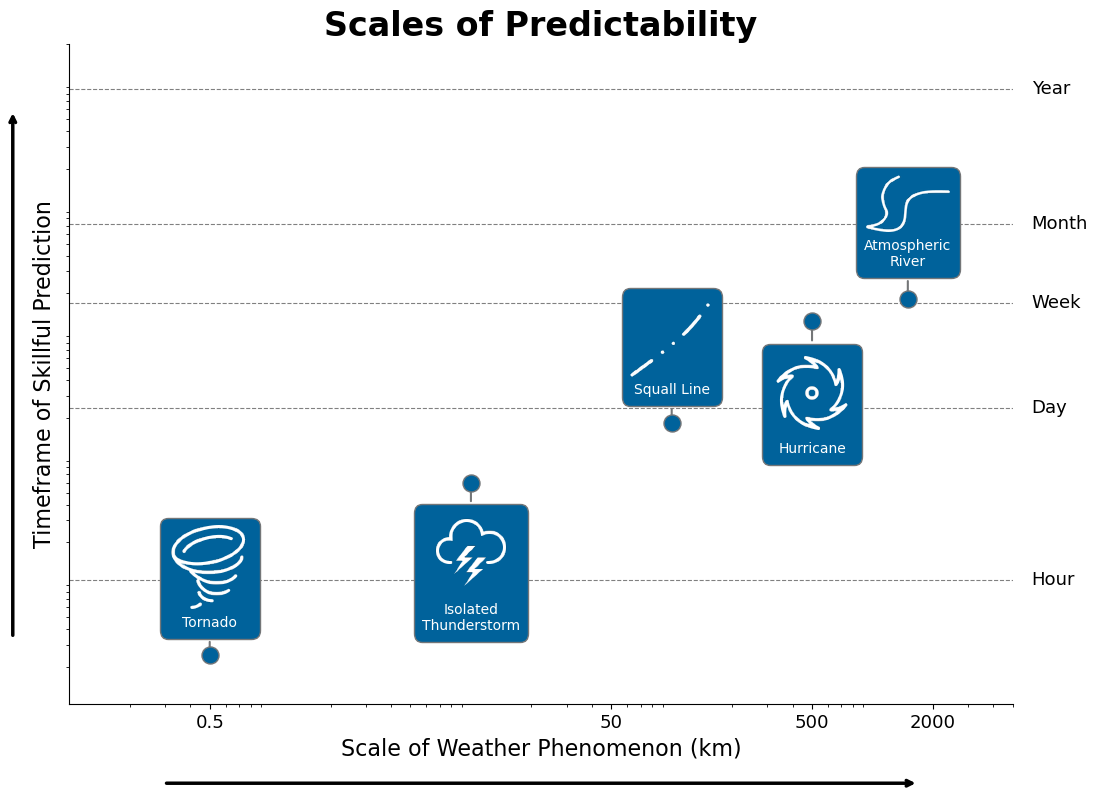

In [24]:
plot_predictability_presentation(phenomena, time_lines, image_paths)